In [ ]:
import functions.cnn_helpers as help_funcs
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import torch

### Define model, criterion and optimizers

In [13]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
IMAGE_SIZE = 52
DEVICE="mps"

# Model
model = help_funcs.CNN_1(out_1 = 32, kernel_cnn_1 = 7, out_2 = 32, kernel_cnn_2 = 7, h = IMAGE_SIZE, w = IMAGE_SIZE)
model = model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

# Criterion
criterion = nn.BCELoss()

In [14]:
model

CNN_1(
  (cnn1): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=same)
  (conv1_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=valid)
  (conv2_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3200, out_features=1, bias=True)
)

### Read splits and create DataSet objects

In [15]:
# Need to integrate in a for loop to go through all splits
# First, do it on a single split and using a few epochs (10)

# Define transform
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

# Create dataset objects
train_dataset = help_funcs.trace('../data/CNN_splits_zscore/fold_0/train', transform=transform)
validation_dataset = help_funcs.trace('../data/CNN_splits_zscore/fold_0/validation', transform=transform)
test_dataset = help_funcs.trace('../data/CNN_splits_zscore/fold_0/test', transform=transform)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(dataset=validation_dataset, batch_size=32)
test_loader = DataLoader(dataset=test_dataset, batch_size=32)



### Train the model

In [16]:
train_loss, train_acc, val_loss, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                                  validation_loader = validation_loader, optimizer = optimizer,
                                                                  model = model, criterion = criterion, device = DEVICE)

In [17]:
val_acc

[17.937304075235108,
 18.768025078369906,
 18.247648902821318,
 17.846394984326018,
 17.739811912225704,
 17.981191222570533,
 18.012539184952978,
 17.855799373040753,
 17.862068965517242,
 17.912225705329153,
 17.724137931034484,
 18.238244514106583,
 18.12539184952978,
 17.877742946708462,
 18.16614420062696,
 17.877742946708462,
 18.539184952978058,
 18.163009404388713,
 18.26332288401254,
 18.078369905956112,
 18.391849529780565,
 18.178683385579937,
 18.115987460815045,
 18.213166144200628,
 18.564263322884013,
 18.413793103448278,
 18.329153605015673,
 18.363636363636363,
 18.363636363636363,
 18.100313479623825,
 18.379310344827587,
 18.363636363636363,
 18.235109717868337,
 18.338557993730408,
 18.213166144200628,
 18.316614420062695,
 18.03448275862069,
 18.313479623824453,
 18.46394984326019,
 18.29780564263323,
 18.329153605015673,
 18.153605015673982,
 18.134796238244515,
 17.896551724137932,
 18.253918495297807,
 18.05015673981191,
 17.968652037617556,
 18.426332288401255,

In [ ]:
# 47 sec training in CPU
# 29 sec training in GPU
# 21 minutes training 500 epochs GPU

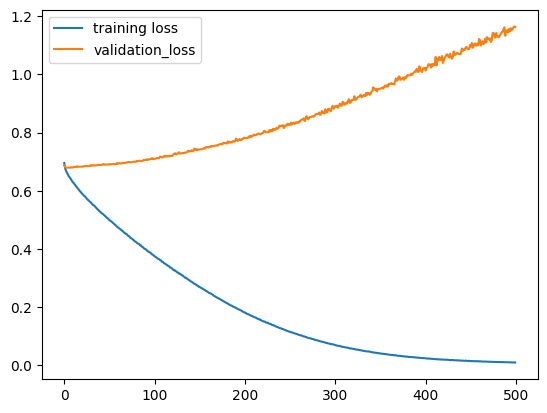

In [26]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation_loss')

plt.legend()

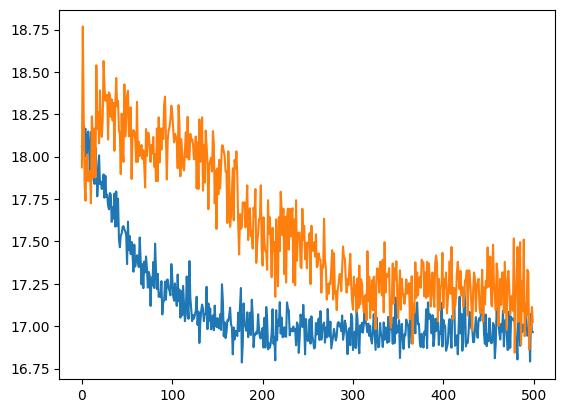

In [27]:
plt.plot(train_acc, label='training loss')
plt.plot(val_acc, label='validation_loss')

In [192]:
def run_predictions(model, test_loader, device):
    """
    Evaluates model performance on test dataset

    Parameters
    ----------
    n_epochs: int
        Number of epochs performed during training.

    Returns
    -------
    train_loss: list
        Training loss.

    """

    y_pred_all = []
    y_pred_score_all = []
    label_all = []

    model.eval()

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            y_pred_score = model(imgs)
            y_pred = (y_pred_score >= 0.5)
            y_pred_all.extend(y_pred.long().view(-1).cpu().numpy())
            y_pred_score_all.extend(y_pred_score.view(-1).cpu().numpy())
            label_all.extend(labels.long().view(-1).numpy())

    y_pred_all = [int(x) for x in y_pred_all]
    y_pred_score_all = [float(x) for x in y_pred_score_all]
    label_all = [int(x) for x in label_all]
    
    return y_pred_all, y_pred_score_all, label_all

In [193]:
all_preds, all_pred_scores, all_labels = run_predictions(model, test_loader, DEVICE)

In [173]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy:.4f}")

print(
    classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3)
)

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]
print("Normalized Confusion Matrix:")
print(cm_norm)

Test Accuracy: 0.5627
              precision    recall  f1-score   support

  0-inactive      0.615     0.707     0.658       379
    1-active      0.450     0.351     0.395       259

    accuracy                          0.563       638
   macro avg      0.533     0.529     0.526       638
weighted avg      0.548     0.563     0.551       638

Normalized Confusion Matrix:
[[0.70712401 0.29287599]
 [0.64864865 0.35135135]]
